In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
data=load_diabetes()

In [7]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
x=data.data
y=data.target

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=13)

In [13]:
from sklearn.linear_model import LinearRegression

In [15]:
lr = LinearRegression()

In [17]:
lr.fit(x_train,y_train)

LinearRegression()

In [19]:
print(lr.coef_)
print(lr.intercept_)

[ -17.28691266 -248.0885923   578.27946674  315.72999856 -571.32572115
  292.43070367  -17.46493017  120.18338433  695.01416778  108.05301725]
150.23367667649734


In [21]:
y_pred=lr.predict(x_test)

In [25]:
from sklearn.metrics import r2_score,mean_squared_error

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score 0.3670103737004131
RMSE 55.715405228997824


In [27]:
from sklearn.linear_model import Ridge
R=Ridge(alpha=100000)

In [29]:
R.fit(x_train,y_train)

Ridge(alpha=100000)

In [31]:
print(R.coef_)
print(R.intercept_)

[ 0.00235217  0.00048153  0.0081667   0.00593153  0.00314816  0.00262199
 -0.00490145  0.00571853  0.00734685  0.00546124]
151.83279504087224


In [43]:
y_pred1=R.predict(x_test)

In [47]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00043029567779040434
RMSE 70.0439153754476


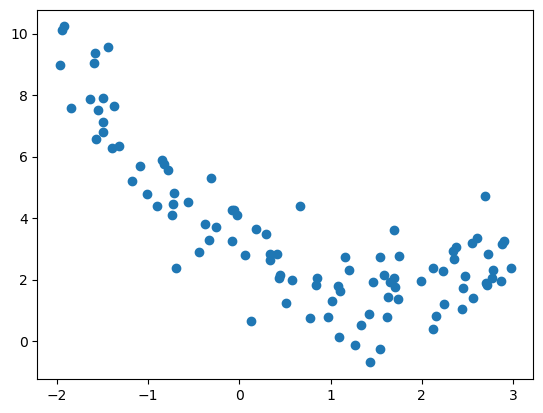

In [53]:
m=100
x1=5* np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3+np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

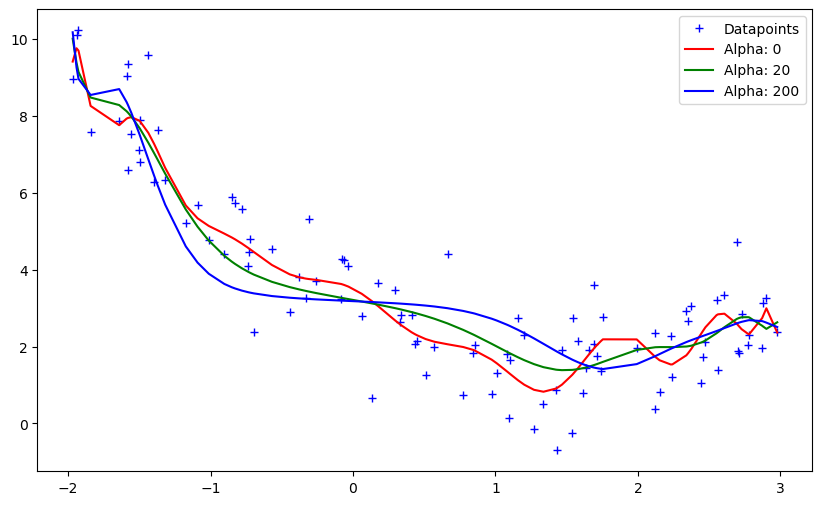

In [55]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [ ]:
# Red line shows overfitting: curve will be very wiggly
# Green line shows balances bias and variance : curve smoother
# Blue line shows underfitting : curve becomes much flatter
